# Uber Fare Prediction Analysis

## Machine Learning Project

This project analyzes Uber trip data and develops a machine learning model to predict fare amounts using trip characteristics such as pickup and drop-off locations, passenger count, and pickup date and time.

## Project Overview

The goal of this project is to analyze Uber fare data, identify the factors that influence trip fares, and develop a machine learning model capable of predicting fare amounts for new trips.

### Objectives

- Load and inspect the Uber fare dataset.
- Clean and preprocess the data.
- Explore fare patterns and trip characteristics.
- Engineer useful features from location and datetime information.
- Train and compare machine learning regression models.
- Evaluate model performance using appropriate regression metrics.
- Use the final model to predict fares for new Uber trips.

## Dataset Overview

The dataset contains historical Uber trip records used to analyze fare patterns and train the prediction model.

### Key Variables

- **fare_amount:** The fare charged for the trip.
- **pickup_datetime:** Date and time when the trip started.
- **pickup_longitude / pickup_latitude:** Geographic coordinates of the pickup location.
- **dropoff_longitude / dropoff_latitude:** Geographic coordinates of the destination.
- **passenger_count:** Number of passengers for the trip.

## 1. Setup and Imports

In [1]:
# Core imports and reproducibility
from pathlib import Path
import os
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
MAX_ROWS = 300_000  # Set to None for the full dataset.
NYC_BOUNDS = {"lat_min": 40.5, "lat_max": 40.9, "lon_min": -74.25, "lon_max": -73.7}

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


def resolve_data_path() -> Path:
    candidates = [
        os.getenv("UBER_CSV_PATH"),
        "../input/uber-fares-dataset/uber.csv",
        "./uber.csv",
        "./data/uber.csv",
    ]
    for candidate in candidates:
        if candidate and Path(candidate).expanduser().exists():
            return Path(candidate).expanduser().resolve()
    raise FileNotFoundError(
        "uber.csv was not found. Set UBER_CSV_PATH or place it in ./data/uber.csv."
    )


DATA_PATH = resolve_data_path()
df_raw = pd.read_csv(DATA_PATH, nrows=MAX_ROWS)

required_columns = {
    "key", "fare_amount", "pickup_datetime", "pickup_longitude",
    "pickup_latitude", "dropoff_longitude", "dropoff_latitude", "passenger_count"
}
missing_columns = required_columns.difference(df_raw.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

print(f"Loaded {len(df_raw):,} rows from {DATA_PATH}")
display(df_raw.head())
display(df_raw.dtypes.rename("dtype").to_frame())


Loaded 200,000 rows from C:\Users\HP\data\uber.csv


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


,dtype
Unnamed: 0,int64
key,object
fare_amount,float64
pickup_datetime,object
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,int64


In [2]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\HP
['.ai-navigator', '.anaconda', '.cache', '.codex', '.conda', '.condarc', '.continuum', '.copilot', '.ipynb_checkpoints', '.ipython', '.jupyter', '.mamba', '.matplotlib', '.ms-ad', '.virtual_documents', '.vscode', '.vscode-shared', 'AppData', 'Application Data', 'artifacts', 'car price pred', 'car price prediction.ipynb', 'car_data_v2.xls', 'car_price_dataset.csv', 'Contacts', 'Cookies', 'data', 'Documents', 'Downloads', 'exercis foda', 'Favorites', 'first assgnt on list ipynb', 'improved disease.ipynb', 'improved_disease_dataset(2).csv', 'income_evaluation (1).csv', 'IntelGraphicsProfiles', 'Linear regression on RealEstate.ipynb', 'Links', 'list creation.ipynb', 'list plus turple 1.ipynb', 'Local Settings', 'machine lerning practical', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'new assignment on list.ipynb', 'new car price .txt', 'new car price predit .txt', 'new excercis sun.ipynb', 'New folder', 'New folder (2)', 'New folder (3)', 'new m.txlt', 'new practice1Folder

In [3]:
import os

for root, dirs, files in os.walk(os.path.expanduser("~/Downloads")):
    for file in files:
        if file.lower().endswith(".csv"):
            print(os.path.join(root, file))

C:\Users\HP/Downloads\AdventureWorks Customer Lookup.csv
C:\Users\HP/Downloads\AdventureWorks Product Lookup.csv
C:\Users\HP/Downloads\AdventureWorks Returns Data.csv
C:\Users\HP/Downloads\AdventureWorks Sales Data 2020.csv
C:\Users\HP/Downloads\Advertising.csv
C:\Users\HP/Downloads\cancer_dataset.csv
C:\Users\HP/Downloads\car_data_v2.csv
C:\Users\HP/Downloads\car_price_dataset (1).csv
C:\Users\HP/Downloads\car_price_dataset.csv
C:\Users\HP/Downloads\car_price_prediction_ (1).csv
C:\Users\HP/Downloads\car_price_prediction_.csv
C:\Users\HP/Downloads\diabetes 1 (1).csv
C:\Users\HP/Downloads\improved_disease_dataset(2).csv
C:\Users\HP/Downloads\income_evaluation (1).csv
C:\Users\HP/Downloads\iris 1 (2).csv
C:\Users\HP/Downloads\population-2010-2019.csv
C:\Users\HP/Downloads\population-2020-2029.csv
C:\Users\HP/Downloads\Real_estate.csv
C:\Users\HP/Downloads\Sales_April_2019.csv
C:\Users\HP/Downloads\water_shortage_balanced.csv
C:\Users\HP/Downloads\.ipynb_checkpoints\car_data_v2-checkpoin

In [4]:
import os

for root, dirs, files in os.walk(r"C:\Users\HP"):
    for file in files:
        if "uber" in file.lower():
            print(os.path.join(root, file))

C:\Users\HP\uber-fares-dataset.ipynb
C:\Users\HP\Uber_Fare_Prediction_Analysis.ipynb
C:\Users\HP\.codex\.tmp\plugins\plugins\nvidia\skills\aiq-deploy\references\kubernetes-helm.md
C:\Users\HP\.ipynb_checkpoints\uber-fares-dataset-checkpoint.ipynb
C:\Users\HP\.ipynb_checkpoints\Uber_Fare_Prediction_Analysis-checkpoint.ipynb
C:\Users\HP\.vscode\extensions\ms-python.vscode-pylance-2026.3.1\dist\bundled\stubs\sklearn\linear_model\_huber.pyi
C:\Users\HP\.vscode\extensions\ms-python.vscode-pylance-2026.3.1\dist\typeshed-fallback\stubs\hvac\hvac\api\auth_methods\kubernetes.pyi
C:\Users\HP\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_huber.py
C:\Users\HP\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\tests\test_huber.py
C:\Users\HP\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\tests\__pycache__\test_huber.cpython-312.pyc
C:\Users\HP\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\__pycache__\_huber.cpython-312.pyc
C:\Users\HP\A

In [5]:
import os

for root, dirs, files in os.walk(r"C:\Users\HP\Downloads"):
    for file in files:
        if file.lower().endswith(".zip"):
            print(os.path.join(root, file))

C:\Users\HP\Downloads\archive(1).zip
C:\Users\HP\Downloads\archive(10).zip
C:\Users\HP\Downloads\archive(11).zip
C:\Users\HP\Downloads\archive(12).zip
C:\Users\HP\Downloads\archive(13).zip
C:\Users\HP\Downloads\archive(14).zip
C:\Users\HP\Downloads\archive(15).zip
C:\Users\HP\Downloads\archive(16).zip
C:\Users\HP\Downloads\archive(17).zip
C:\Users\HP\Downloads\archive(2).zip
C:\Users\HP\Downloads\archive(3).zip
C:\Users\HP\Downloads\archive(4).zip
C:\Users\HP\Downloads\archive(5).zip
C:\Users\HP\Downloads\archive(6).zip
C:\Users\HP\Downloads\archive(7).zip
C:\Users\HP\Downloads\archive(8).zip
C:\Users\HP\Downloads\archive(9).zip
C:\Users\HP\Downloads\archive.zip
C:\Users\HP\Downloads\Enterprise_Sales_Pipeline_Challenge_35 (1).zip
C:\Users\HP\Downloads\Enterprise_Sales_Pipeline_Challenge_35.zip
C:\Users\HP\Downloads\OpenAI ChatGPT Desktop 2025.1125.240.0 [FileCR].zip
C:\Users\HP\Downloads\SampleSuperstore.csv(1).zip
C:\Users\HP\Downloads\SampleSuperstore.csv.zip
C:\Users\HP\Downloads\ti

In [6]:
import os

for root, dirs, files in os.walk(r"C:\Users\HP\Downloads"):
    for file in files:
        if file.lower().endswith(".zip"):
            print(os.path.join(root, file))

C:\Users\HP\Downloads\archive(1).zip
C:\Users\HP\Downloads\archive(10).zip
C:\Users\HP\Downloads\archive(11).zip
C:\Users\HP\Downloads\archive(12).zip
C:\Users\HP\Downloads\archive(13).zip
C:\Users\HP\Downloads\archive(14).zip
C:\Users\HP\Downloads\archive(15).zip
C:\Users\HP\Downloads\archive(16).zip
C:\Users\HP\Downloads\archive(17).zip
C:\Users\HP\Downloads\archive(2).zip
C:\Users\HP\Downloads\archive(3).zip
C:\Users\HP\Downloads\archive(4).zip
C:\Users\HP\Downloads\archive(5).zip
C:\Users\HP\Downloads\archive(6).zip
C:\Users\HP\Downloads\archive(7).zip
C:\Users\HP\Downloads\archive(8).zip
C:\Users\HP\Downloads\archive(9).zip
C:\Users\HP\Downloads\archive.zip
C:\Users\HP\Downloads\Enterprise_Sales_Pipeline_Challenge_35 (1).zip
C:\Users\HP\Downloads\Enterprise_Sales_Pipeline_Challenge_35.zip
C:\Users\HP\Downloads\OpenAI ChatGPT Desktop 2025.1125.240.0 [FileCR].zip
C:\Users\HP\Downloads\SampleSuperstore.csv(1).zip
C:\Users\HP\Downloads\SampleSuperstore.csv.zip
C:\Users\HP\Downloads\ti

In [7]:
import os
import zipfile

downloads = r"C:\Users\HP\Downloads"

for file in os.listdir(downloads):
    if file.lower().endswith(".zip"):
        path = os.path.join(downloads, file)
        try:
            with zipfile.ZipFile(path, "r") as z:
                for name in z.namelist():
                    if "uber" in name.lower():
                        print(file, "---->", name)
        except:
            pass

archive(17).zip ----> uber.csv


In [8]:
from pathlib import Path

p = Path(r"C:\Users\HP\data\uber.csv")

print("File exists:", p.exists())
print("File location:", p)

File exists: True
File location: C:\Users\HP\data\uber.csv


## 2. Data Quality Assessment

This section examines the structure and quality of the Uber fare dataset, including data types, missing values, unique values, and descriptive statistics.

In [9]:
# Baseline data-quality report
quality_report = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_pct": df_raw.isna().mean().mul(100).round(3),
    "unique": df_raw.nunique(dropna=True),
})
display(quality_report)
display(df_raw.describe(include="all").T)


,dtype,missing,missing_pct,unique
Unnamed: 0,int64,0,0.0,200000
key,object,0,0.0,200000
fare_amount,float64,0,0.0,1244
pickup_datetime,object,0,0.0,196629
pickup_longitude,float64,0,0.0,71066
pickup_latitude,float64,0,0.0,83835
dropoff_longitude,float64,1,0.0,76894
dropoff_latitude,float64,1,0.0,90585
passenger_count,int64,0,0.0,8


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,200000.0,NaN,NaN,NaN,27712503.68235,16013822.212829,1.0,13825346.25,27745495.0,41555300.75,55423567.0
key,200000,200000,2015-05-07 19:52:06.0000003,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare_amount,200000.0,NaN,NaN,NaN,11.359955,9.901776,-52.0,6.0,8.5,12.5,499.0
pickup_datetime,200000,196629,2014-04-13 18:19:00 UTC,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_longitude,200000.0,NaN,NaN,NaN,-72.527638,11.437787,-1340.64841,-73.992065,-73.981823,-73.967154,57.418457
pickup_latitude,200000.0,NaN,NaN,NaN,39.935885,7.720539,-74.015515,40.734796,40.752592,40.767158,1644.421482
dropoff_longitude,199999.0,NaN,NaN,NaN,-72.525292,13.117408,-3356.6663,-73.991407,-73.980093,-73.963658,1153.572603
dropoff_latitude,199999.0,NaN,NaN,NaN,39.92389,6.794829,-881.985513,40.733823,40.753042,40.768001,872.697628
passenger_count,200000.0,NaN,NaN,NaN,1.684535,1.385997,0.0,1.0,1.0,2.0,208.0


## 3. Data Cleaning and Preprocessing

This section cleans and prepares the Uber fare dataset for analysis and machine learning. It handles missing or invalid values, converts variables to appropriate data types, and filters unrealistic trip records to improve data quality.

In [10]:
def clean_uber_data(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    '''Return cleaned trips and an audit table of filtering stages.'''
    data = frame.copy()
    audit = [("raw", len(data))]

    numeric_cols = [
        "fare_amount", "pickup_longitude", "pickup_latitude",
        "dropoff_longitude", "dropoff_latitude", "passenger_count"
    ]
    data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric, errors="coerce")
    data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"], errors="coerce", utc=True)

    essential = ["fare_amount", "pickup_datetime", "pickup_longitude", "pickup_latitude",
                 "dropoff_longitude", "dropoff_latitude", "passenger_count"]
    data = data.dropna(subset=essential)
    audit.append(("after_missing_values", len(data)))

    data = data.loc[data["fare_amount"].gt(0) & data["passenger_count"].between(1, 6)]
    audit.append(("after_fare_and_passenger_checks", len(data)))

    b = NYC_BOUNDS
    coordinate_mask = (
        data["pickup_latitude"].between(b["lat_min"], b["lat_max"])
        & data["dropoff_latitude"].between(b["lat_min"], b["lat_max"])
        & data["pickup_longitude"].between(b["lon_min"], b["lon_max"])
        & data["dropoff_longitude"].between(b["lon_min"], b["lon_max"])
    )
    data = data.loc[coordinate_mask].copy()
    audit.append(("after_coordinate_checks", len(data)))

    data["passenger_count"] = data["passenger_count"].astype("int8")
    audit_df = pd.DataFrame(audit, columns=["stage", "rows_remaining"])
    audit_df["rows_removed_at_stage"] = -audit_df["rows_remaining"].diff().fillna(0).astype(int)
    audit_df["retained_pct"] = audit_df["rows_remaining"].div(len(frame)).mul(100).round(2)
    return data.reset_index(drop=True), audit_df


df_clean, cleaning_audit = clean_uber_data(df_raw)
display(cleaning_audit)
assert len(df_clean) > 0, "No rows survived the cleaning rules."


,stage,rows_remaining,rows_removed_at_stage,retained_pct
0,raw,200000,0,100.00
1,after_missing_values,199999,1,100.00
2,after_fare_and_passenger_checks,199268,731,99.63
3,after_coordinate_checks,194777,4491,97.39


## 4. Feature Engineering

This section creates additional features from the cleaned Uber trip data to improve fare prediction. Geographic coordinates are used to calculate trip distances and proximity to important New York City landmarks, while datetime information is transformed into useful time-based features.

In [11]:
EARTH_RADIUS_KM = 6_371.0088
LANDMARKS = {
    "jfk": (40.6413, -73.7781),
    "lga": (40.7769, -73.8740),
    "ewr": (40.6895, -74.1745),
    "midtown": (40.7549, -73.9840),
}
PROXIMITY_KM = {"jfk": 3.0, "lga": 3.0, "ewr": 3.0, "midtown": 2.0}


def haversine_km(lat1, lon1, lat2, lon2):
    '''Vectorized great-circle distance in kilometers.'''
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def manhattan_km(lat1, lon1, lat2, lon2):
    '''Axis-aligned distance: vertical component + horizontal component.'''
    vertical = haversine_km(lat1, lon1, lat2, lon1)
    horizontal = haversine_km(lat1, lon1, lat1, lon2)
    return vertical + horizontal


def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    '''Create model-ready numeric features from cleaned/raw-compatible columns.'''
    data = frame.copy()
    dt = pd.to_datetime(data["pickup_datetime"], errors="coerce", utc=True)

    p_lat, p_lon = data["pickup_latitude"], data["pickup_longitude"]
    d_lat, d_lon = data["dropoff_latitude"], data["dropoff_longitude"]
    data["haversine_km"] = haversine_km(p_lat, p_lon, d_lat, d_lon)
    data["manhattan_km"] = manhattan_km(p_lat, p_lon, d_lat, d_lon)
    data["hour"] = dt.dt.hour.astype("int8")
    data["day_of_week"] = dt.dt.dayofweek.astype("int8")
    data["month"] = dt.dt.month.astype("int8")
    data["year"] = dt.dt.year.astype("int16")
    data["is_weekend"] = dt.dt.dayofweek.ge(5).astype("int8")

    for name, (lat, lon) in LANDMARKS.items():
        pickup_distance = haversine_km(p_lat, p_lon, lat, lon)
        dropoff_distance = haversine_km(d_lat, d_lon, lat, lon)
        min_distance = np.minimum(pickup_distance, dropoff_distance)
        data[f"min_distance_to_{name}_km"] = min_distance
        data[f"near_{name}"] = (min_distance <= PROXIMITY_KM[name]).astype("int8")

    return data


df = engineer_features(df_clean)
display(df.head())
display(df[["haversine_km", "manhattan_km"]].describe())


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,haversine_km,manhattan_km,hour,day_of_week,month,year,is_weekend,min_distance_to_jfk_km,near_jfk,min_distance_to_lga_km,near_lga,min_distance_to_ewr_km,near_ewr,min_distance_to_midtown_km,near_midtown
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683325,1.708840,19,3,5,2015,0,20.773639,0,11.431253,0,15.219260,0,2.271674,0
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457593,2.487325,20,4,7,2009,0,20.637980,0,10.586984,0,15.783099,0,1.035695,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036384,7.123303,21,0,8,2009,0,21.332572,0,7.472693,0,15.377900,0,2.368750,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661686,2.300374,8,4,6,2009,0,23.559489,0,8.230946,0,20.157355,0,4.051450,0
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475456,5.957060,17,3,8,2014,0,16.854259,0,5.637520,0,18.754664,0,1.159199,1


,haversine_km,manhattan_km
count,194777.000000,194777.000000
mean,3.305545,4.260321
std,3.550625,4.700389
min,0.000000,0.000000
25%,1.256582,1.602816
50%,2.156608,2.767408
75%,3.904306,5.033697
max,35.341909,49.701605


## 5. Exploratory Data Analysis (EDA)

This section explores patterns and relationships within the cleaned Uber fare data. Visualizations are used to examine the relationship between trip distance and fare amount, changes in median fares by pickup hour, and correlations among important numerical features.

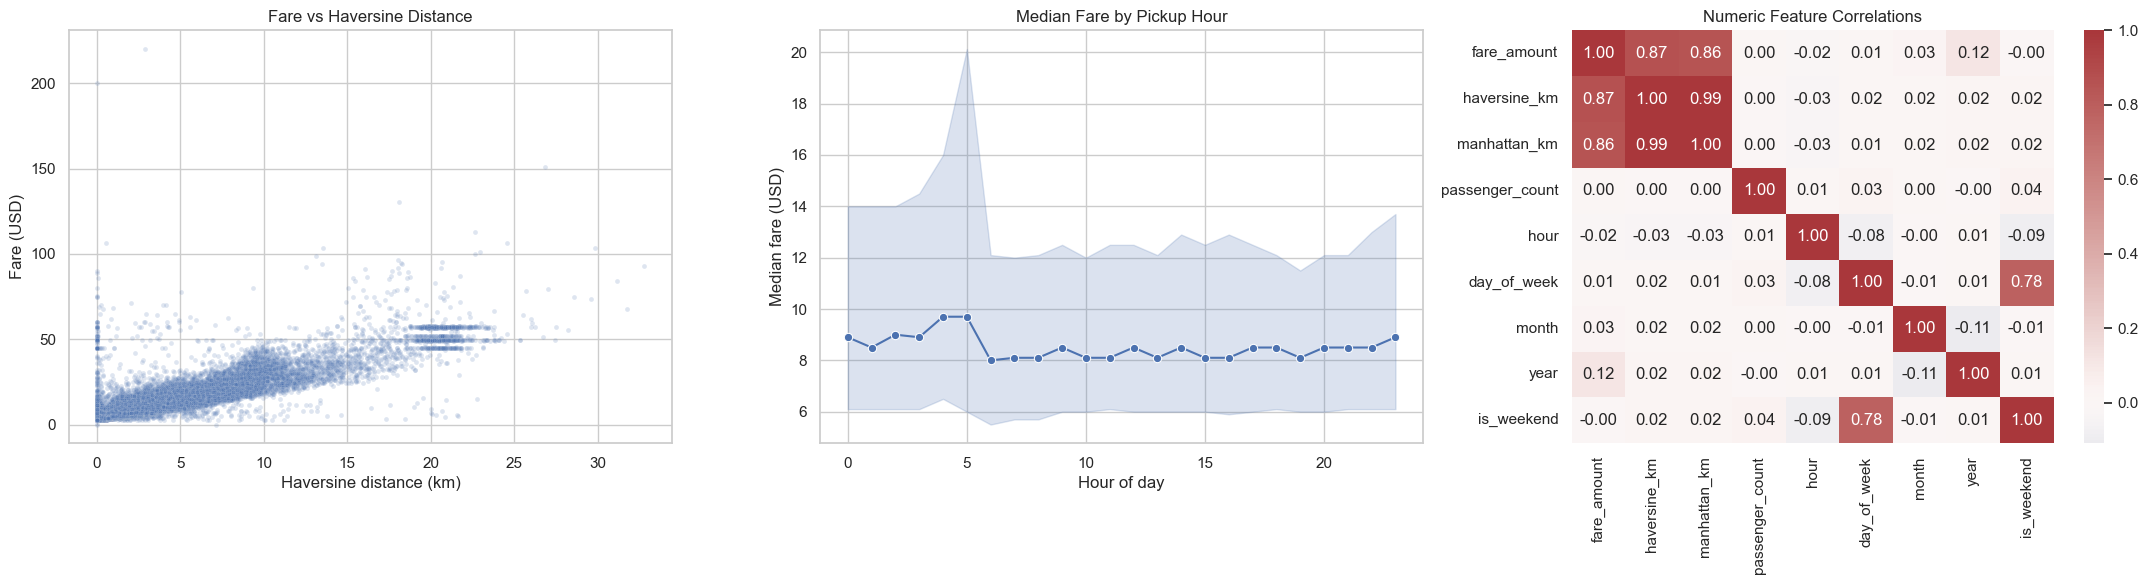

In [12]:
eda_sample = df.sample(min(50_000, len(df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.scatterplot(data=eda_sample, x="haversine_km", y="fare_amount", alpha=0.18,
                s=12, ax=axes[0], rasterized=True)
axes[0].set(title="Fare vs Haversine Distance", xlabel="Haversine distance (km)", ylabel="Fare (USD)")

sns.lineplot(data=eda_sample, x="hour", y="fare_amount", estimator="median",
             errorbar=("pi", 50), marker="o", ax=axes[1])
axes[1].set(title="Median Fare by Pickup Hour", xlabel="Hour of day", ylabel="Median fare (USD)")

corr_features = ["fare_amount", "haversine_km", "manhattan_km", "passenger_count",
                 "hour", "day_of_week", "month", "year", "is_weekend"]
sns.heatmap(eda_sample[corr_features].corr(), cmap="vlag", center=0, annot=True,
            fmt=".2f", square=False, ax=axes[2])
axes[2].set_title("Numeric Feature Correlations")

plt.tight_layout()
plt.show()


## 6. Model Preparation and Training

This section prepares the engineered features for machine learning, separates the data into training and testing sets, and builds regression models for predicting Uber fare amounts. Multiple models are trained to identify the approach that provides the most accurate fare predictions.

In [13]:
FEATURE_COLUMNS = [
    "pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude",
    "passenger_count", "haversine_km", "manhattan_km", "hour", "day_of_week",
    "month", "year", "is_weekend",
] + [item for name in LANDMARKS for item in (f"min_distance_to_{name}_km", f"near_{name}")]

X = df[FEATURE_COLUMNS]
y = df["fare_amount"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

linear = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

random_forest = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=250, min_samples_leaf=3, max_features=0.8,
        n_jobs=-1, random_state=RANDOM_STATE
    )),
])

try:
    from xgboost import XGBRegressor
    boosted_estimator = XGBRegressor(
        n_estimators=800, learning_rate=0.05, max_depth=8,
        subsample=0.85, colsample_bytree=0.85, objective="reg:squarederror",
        eval_metric="rmse", n_jobs=-1, random_state=RANDOM_STATE
    )
    BOOSTED_NAME = "XGBoost"
except ImportError:
    try:
        from lightgbm import LGBMRegressor
        boosted_estimator = LGBMRegressor(
            n_estimators=800, learning_rate=0.05, num_leaves=63,
            subsample=0.85, colsample_bytree=0.85, n_jobs=-1,
            random_state=RANDOM_STATE, verbosity=-1
        )
        BOOSTED_NAME = "LightGBM"
    except ImportError:
        boosted_estimator = HistGradientBoostingRegressor(
            max_iter=350, learning_rate=0.07, max_leaf_nodes=63,
            l2_regularization=1.0, random_state=RANDOM_STATE
        )
        BOOSTED_NAME = "HistGradientBoosting (fallback)"

boosted = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", boosted_estimator),
])

models = {
    "Linear Regression": TransformedTargetRegressor(regressor=linear, func=np.log1p, inverse_func=np.expm1),
    "Random Forest": TransformedTargetRegressor(regressor=random_forest, func=np.log1p, inverse_func=np.expm1),
    BOOSTED_NAME: TransformedTargetRegressor(regressor=boosted, func=np.log1p, inverse_func=np.expm1),
}
print(f"Train rows: {len(X_train):,}; test rows: {len(X_test):,}; boosted model: {BOOSTED_NAME}")


Train rows: 155,821; test rows: 38,956; boosted model: XGBoost


## 7. Model Evaluation and Comparison

This section evaluates and compares the trained regression models using RMSE, MAE, and R². Each model is tested on the holdout dataset, and the model with the lowest RMSE is selected as the best-performing model for fare prediction.

In [14]:
def regression_metrics(y_true, y_pred) -> dict:
    return {
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


fitted_models, results = {}, []
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    predictions = np.maximum(model.predict(X_test), 0)
    fitted_models[name] = model
    results.append({"Model": name, **regression_metrics(y_test, predictions)})

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df.style.format({"RMSE": "{:.3f}", "MAE": "{:.3f}", "R2": "{:.4f}"}))

best_model_name = results_df.loc[0, "Model"]
best_model = fitted_models[best_model_name]
print(f"Best holdout model by RMSE: {best_model_name}")


Training Linear Regression...
Training Random Forest...
Training XGBoost...


,Model,RMSE,MAE,R2
0,XGBoost,3.824,1.553,0.8433
1,Random Forest,3.906,1.662,0.8364
2,Linear Regression,8.895,2.618,0.1518


Best holdout model by RMSE: XGBoost


## 8. Feature Importance and Model Interpretation

This section interprets the best-performing machine learning model by examining feature importance. It identifies the variables that contribute most strongly to Uber fare predictions and helps explain the factors driving the model's predictions.

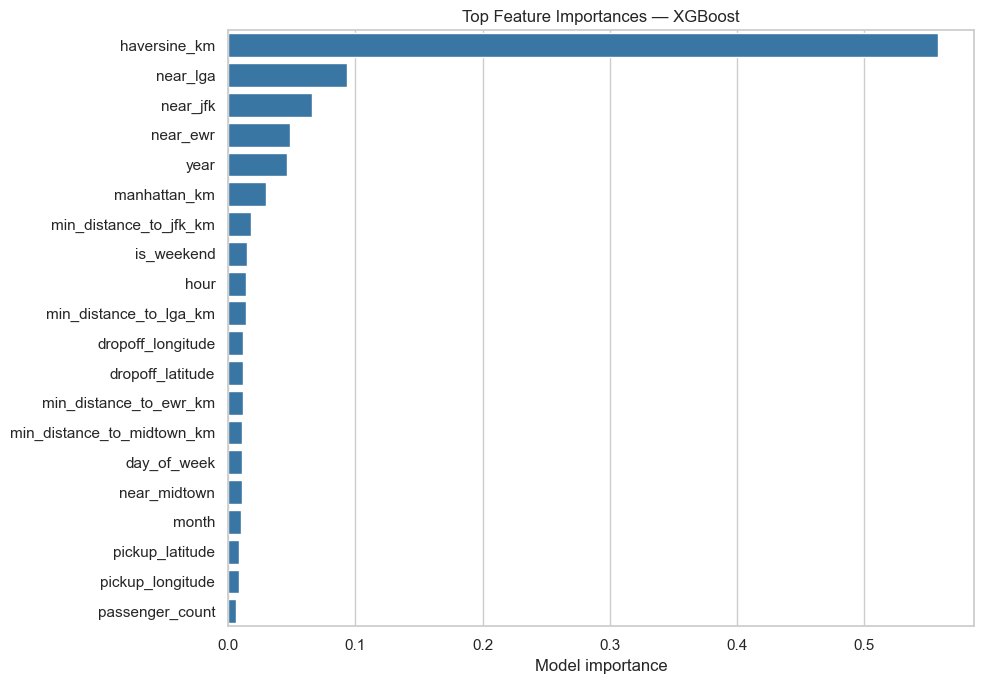

In [15]:
importance_source = fitted_models.get(BOOSTED_NAME)
inner_pipeline = importance_source.regressor_
tree_model = inner_pipeline.named_steps["model"]

if hasattr(tree_model, "feature_importances_"):
    importance = pd.Series(tree_model.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)
    plt.figure(figsize=(10, 7))
    sns.barplot(x=importance.head(20).values, y=importance.head(20).index, color="#2878B5")
    plt.title(f"Top Feature Importances — {BOOSTED_NAME}")
    plt.xlabel("Model importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print(f"{BOOSTED_NAME} does not expose feature_importances_. Use sklearn.inspection.permutation_importance.")


## 9. Model Saving and Deployment Preparation

The best-performing model is saved as a reusable model artifact for future predictions and deployment. Supporting metadata, including the selected features, model performance metrics, geographic boundaries, and landmark information, is also stored to ensure reproducibility.

In [16]:
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_PATH = ARTIFACT_DIR / "uber_fare_model.joblib"

artifact = {
    "model": best_model,
    "model_name": best_model_name,
    "feature_columns": FEATURE_COLUMNS,
    "nyc_bounds": NYC_BOUNDS,
    "landmarks": LANDMARKS,
    "proximity_km": PROXIMITY_KM,
    "metrics": results_df.to_dict(orient="records"),
}
joblib.dump(artifact, ARTIFACT_PATH)

metadata = {k: v for k, v in artifact.items() if k != "model"}
(ARTIFACT_DIR / "model_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print(f"Saved model bundle to {ARTIFACT_PATH.resolve()}")


Saved model bundle to C:\Users\HP\artifacts\uber_fare_model.joblib


## 10. Fare Prediction Function

This section defines a reusable prediction function that loads the saved machine learning model and predicts the fare for a new Uber trip. The function validates the trip inputs, prepares the required features, and returns the predicted fare amount.

In [17]:
def predict_fare(
    pickup_datetime,
    pickup_lat,
    pickup_lon,
    dropoff_lat,
    dropoff_lon,
    passenger_count,
    artifact_path="artifacts/uber_fare_model.joblib",
) -> float:
    '''Predict one Uber fare from raw trip inputs and return USD rounded to cents.'''
    bundle = joblib.load(artifact_path)
    b = bundle["nyc_bounds"]

    values = np.asarray([pickup_lat, pickup_lon, dropoff_lat, dropoff_lon], dtype=float)
    if not np.isfinite(values).all():
        raise ValueError("All coordinates must be finite numbers.")
    if not (b["lat_min"] <= pickup_lat <= b["lat_max"] and b["lat_min"] <= dropoff_lat <= b["lat_max"]):
        raise ValueError("Pickup and dropoff latitudes must be within NYC bounds.")
    if not (b["lon_min"] <= pickup_lon <= b["lon_max"] and b["lon_min"] <= dropoff_lon <= b["lon_max"]):
        raise ValueError("Pickup and dropoff longitudes must be within NYC bounds.")
    if isinstance(passenger_count, bool) or int(passenger_count) != passenger_count or not 1 <= int(passenger_count) <= 6:
        raise ValueError("passenger_count must be an integer from 1 through 6.")
    timestamp = pd.to_datetime(pickup_datetime, errors="coerce", utc=True)
    if pd.isna(timestamp):
        raise ValueError("pickup_datetime must be parseable as a timestamp.")

    raw = pd.DataFrame([{
        "pickup_datetime": timestamp,
        "pickup_latitude": float(pickup_lat),
        "pickup_longitude": float(pickup_lon),
        "dropoff_latitude": float(dropoff_lat),
        "dropoff_longitude": float(dropoff_lon),
        "passenger_count": int(passenger_count),
    }])
    features = engineer_features(raw)[bundle["feature_columns"]]
    prediction = float(bundle["model"].predict(features)[0])
    return round(max(prediction, 0.0), 2)


# Example: Midtown Manhattan to JFK
example_fare = predict_fare(
    pickup_datetime="2015-06-15 18:30:00 UTC",
    pickup_lat=40.7580,
    pickup_lon=-73.9855,
    dropoff_lat=40.6413,
    dropoff_lon=-73.7781,
    passenger_count=2,
)
print(f"Predicted fare: ${example_fare:,.2f}")


Predicted fare: $57.74


## 11. Conclusion and Business Recommendations

### Key Findings

- Trip distance is the strongest factor influencing Uber fare amounts.
- The XGBoost model achieved the best predictive performance among the models evaluated.
- Location-related features, including proximity to major NYC airports, contribute to fare prediction.
- Data cleaning and feature engineering improved the quality of the dataset used for modelling.
- The final model can generate fare predictions for new Uber trips using pickup, drop-off, time, and passenger information.

### Business Recommendations

- Use trip distance and geographic information as key inputs when estimating fares.
- Incorporate airport and high-demand location indicators into pricing systems.
- Regularly retrain the model with newer trip data to account for changes in travel and pricing patterns.
- Monitor prediction errors and unusual trips to maintain model reliability.
- The trained model can serve as the foundation for a fare-estimation application or deployment system.

### Final Outcome

This project demonstrates an end-to-end machine learning workflow covering data validation, cleaning, exploratory analysis, feature engineering, model training, evaluation, model selection, and prediction. The final XGBoost model was saved for reuse and successfully generated a fare prediction for a new trip.